## Process similar claims and subsample for contradiction analysis

In [1]:
import pandas as pd

court_cases = pd.read_csv('../clean_data_with_details.csv')
print("Loaded court cases:", court_cases.shape)

similar_claims = pd.read_csv('../results/similarity_report.csv') # All claims similarities
print("Loaded similar claims:", similar_claims.shape)

Loaded court cases: (3303, 18)
Loaded similar claims: (54815685, 9)


<Axes: title={'center': 'Distribution of Similarity Scores between Case Claims'}, ylabel='Frequency'>

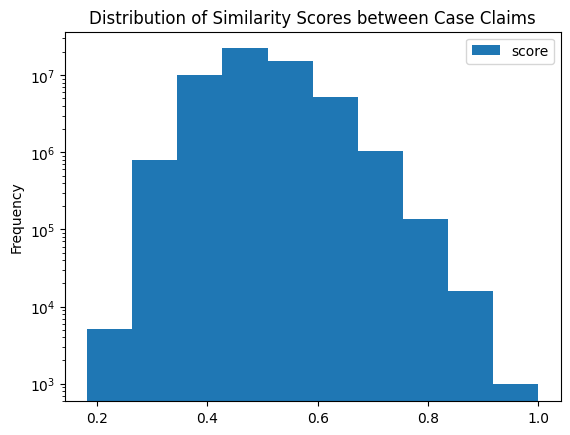

In [3]:
similar_claims.plot.hist(column='score', bins=10, logy=True, title='Distribution of Similarity Scores between Case Claims')

In [ ]:
# Get the similarity of ALL claim pairs [done]
# Uniformly select 10K claim pairs based on similarity
# Look at where contradicting claims appear in distribution
# Pray its not uniform

In [4]:
# Sample 10K claim pairs uniformly across similarity scores
subsample_data = pd.concat([
    # similar_claims[similar_claims['score'] <= 0.1].sample(n=1000, random_state=42), # zero in this bin
    # similar_claims[(similar_claims['score'] > 0.1) & (similar_claims['score'] <= 0.2)].sample(n=1000, random_state=42), # zero in this bin too
    similar_claims[(similar_claims['score'] > 0.2) & (similar_claims['score'] <= 0.3) & (similar_claims['name1'] != similar_claims['name2'])].sample(n=1000, random_state=42),
    similar_claims[(similar_claims['score'] > 0.3) & (similar_claims['score'] <= 0.4) & (similar_claims['name1'] != similar_claims['name2'])].sample(n=1000, random_state=42),
    similar_claims[(similar_claims['score'] > 0.4) & (similar_claims['score'] <= 0.5) & (similar_claims['name1'] != similar_claims['name2'])].sample(n=1000, random_state=42),
    similar_claims[(similar_claims['score'] > 0.5) & (similar_claims['score'] <= 0.6) & (similar_claims['name1'] != similar_claims['name2'])].sample(n=1000, random_state=42),
    similar_claims[(similar_claims['score'] > 0.6) & (similar_claims['score'] <= 0.7) & (similar_claims['name1'] != similar_claims['name2'])].sample(n=1000, random_state=42),
    similar_claims[(similar_claims['score'] > 0.7) & (similar_claims['score'] <= 0.8) & (similar_claims['name1'] != similar_claims['name2'])].sample(n=1000, random_state=42),
    similar_claims[(similar_claims['score'] > 0.8) & (similar_claims['score'] <= 0.9) & (similar_claims['name1'] != similar_claims['name2'])].sample(n=1000, random_state=42),
    similar_claims[(similar_claims['score'] > 0.9) & (similar_claims['name1'] != similar_claims['name2'])].sample(n=1000, random_state=42),
])

In [5]:
subsample_data_with_facts = subsample_data.merge(
    court_cases[['docket', 'name', 'facts', 'api_question', 'api_conclusion']],
    left_on=['docket1', 'name1'],
    right_on=['docket', 'name'],
    how='left'
)

subsample_data_with_facts.rename(
    columns={
        'facts': 'facts1',
        'api_question': 'api_question1',
        'api_conclusion': 'api_conclusion1'
    },
    inplace=True
)
subsample_data_with_facts.drop(columns=['docket', 'name'], inplace=True)

subsample_data_with_facts = subsample_data_with_facts.merge(
    court_cases[['docket', 'name', 'facts', 'api_question', 'api_conclusion']],
    left_on=['docket2', 'name2'],
    right_on=['docket', 'name'],
    how='left'
)

subsample_data_with_facts.rename(
    columns={
        'facts': 'facts2',
        'api_question': 'api_question2',
        'api_conclusion': 'api_conclusion2'
    },
    inplace=True
)
subsample_data_with_facts.drop(columns=['docket', 'name'], inplace=True)

subsample_data_with_facts = subsample_data_with_facts[['claim1', 'docket1', 'name1', 'facts1', 'api_question1', 'api_conclusion1', 'claim2', 'docket2', 'name2', 'facts2', 'api_question2', 'api_conclusion2', 'score']]

<Axes: title={'center': 'Distribution of Similarity Scores in Subsample'}, ylabel='Frequency'>

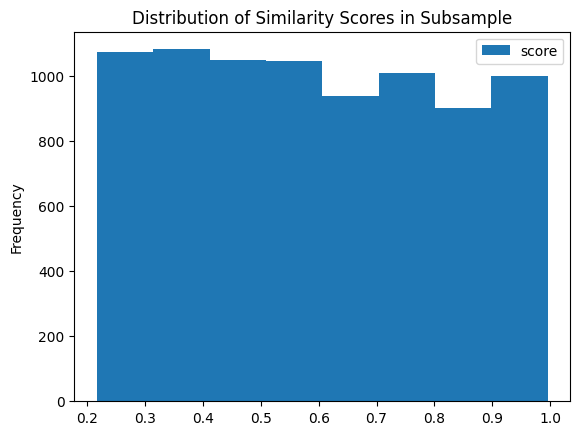

In [6]:
subsample_data_with_facts.plot.hist(column='score', bins=8, title='Distribution of Similarity Scores in Subsample')

In [7]:
# Contradiction Prompt
PROMPT_TEMPLATE = """You are a legal expert. Read two short claims from different cases and the two cases' associated facts, legal questions, and conclusions.
Decide whether the two claims are contradicting (negation or opposite entailment), or consistent (when they are unrelated or entail).
You must output an explanation for your decision in the "explanation" field. Then, also provide a decision in the "contradiction" field: "contradiction" if the claims are contradicting, and "consistent" if they are not.

## Output Format:
Return a JSON object in the following format:
```json
{{
    "explanation": "...",
    "contradiction": "<contradiction/consistent>",
    ...
}}
```

Claim 1: {claim1}
Claim 2: {claim2}

Claim 1 Case Evidence:
Facts: {facts1}
Legal Question: {api_question1}
Conclusion: {api_conclusion1}

Claim 2 Case Evidence:
Facts: {facts2}
Legal Question: {api_question2}
Conclusion: {api_conclusion2}
"""

subsample_data_with_facts['prompt'] = subsample_data_with_facts.apply(lambda row: PROMPT_TEMPLATE.format(
    **row
), axis=1)

In [8]:
subsample_data_with_facts.to_json('../subsampled_claims_for_contradiction_analysis.jsonl', orient='records', lines=True)

In [9]:
# Overlap Prompt
PROMPT_TEMPLATE = """You are a legal expert. Read two short claims from different cases and the two cases' associated facts, legal questions, and conclusions.
Decide whether the two claims are saying the same thing (being redundant) or are meaningfully different regarding their meaning.
You must output an explanation for your decision in the "explanation" field. Then, also provide a decision in the "overlap" field: "redundant" if the claims are redundant, and "different" if they are not.

## Output Format:
Return a JSON object in the following format:
```json
{{
    "explanation": "...",
    "overlap": "<redundant/different>",
    ...
}}
```

Claim 1: {claim1}
Claim 2: {claim2}

Claim 1 Case Evidence:
Facts: {facts1}
Legal Question: {api_question1}
Conclusion: {api_conclusion1}

Claim 2 Case Evidence:
Facts: {facts2}
Legal Question: {api_question2}
Conclusion: {api_conclusion2}
"""

subsample_data_with_facts['prompt'] = subsample_data_with_facts.apply(lambda row: PROMPT_TEMPLATE.format(
    **row
), axis=1)

In [10]:
subsample_data_with_facts.to_json('../subsampled_claims_for_overlap_analysis.jsonl', orient='records', lines=True)

In [12]:
with open('../subsampled_claims_for_contradiction_analysis.jsonl', 'r') as f1, open('../subsampled_claims_for_overlap_analysis.jsonl', 'r') as f2:
	content1 = f1.read()
	content2 = f2.read()
	assert content1 != content2, "The two files are identical!"
print("The two files are not identical.")

The two files are not identical.


## Prompt LLM

In [ ]:
# Generate LLM outputs for contradiction analysis
!python ../gemma3_vllm_flexible.py \
  --prompts ../subsampled_claims_for_contradiction_analysis.jsonl \
  --output ../subsampled_claims_for_contradiction_analysis_vllm.jsonl \
  --tp 4

In [ ]:
# Generate LLM outputs for overlap analysis
!python ../gemma3_vllm_flexible.py \
  --prompts ../subsampled_claims_for_overlap_analysis.jsonl \
  --output ../subsampled_claims_for_overlap_analysis_vllm.jsonl \
  --tp 4

## Analyze LLM responses